# Uncertainty Quantification — Khoảng dự đoán giá đối thủ

**Cấu phần (iii)** của đề bài. Chuyển từ dự đoán **một con số** sang dự đoán **một khoảng**.

```
Trước:  giá đối thủ ≈ 114.000đ
Sau  :  giá đối thủ ≈ 114.000đ,  khoảng tin cậy 90%: [95.000đ – 138.000đ]
```

---

## Vì sao bài này cần UQ

| Phát hiện từ tuần 2 | Hàm ý |
|---|---|
| MAE ~18.000đ là **sàn nhiễu** — 8 hướng cải thiện đều thất bại | Không giảm được sai số → phải **đo** nó |
| Model chỉ tái tạo **70,3%** độ dao động thật | Model tự nó đã thiếu tự tin |
| **MAPE phẳng ~14,7%** ở mọi giờ, mọi quãng đường | Sai số mang tính **nhân**, không phải **cộng** |

Dòng cuối quyết định thiết kế: khoảng dự đoán nên tính theo **%**, không phải theo **số tiền cố định**.

---

## Ba phương pháp so sánh

| # | Phương pháp | Khoảng | Bảo đảm phủ? |
|---|---|---|---|
| **1** | Conformal cơ bản | `ŷ ± q` — **cố định** cho mọi chuyến | ✅ Có |
| **2** | Conformal **chuẩn hoá** ⭐ | `ŷ × (1 ± q)` — **co giãn theo giá** | ✅ Có |
| **3** | Conformal **theo nhóm** (Mondrian) | Mỗi khung giờ một `q` riêng | ✅ Có (từng nhóm) |

Cả 3 đều **không cần train thêm** — chỉ dùng lại phần dư trên tập `calibration`.

---

## Nguyên tắc chống rò rỉ

```
TRAIN        →  train model                    (đã làm tuần 2)
CALIBRATION  →  tính ngưỡng q                  615.908 dòng — CHƯA ĐỤNG
TEST         →  đánh giá coverage              864.360 dòng — mở 1 lần
```

⚠️ Tuyệt đối **không** dùng `test` để chọn `q`.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90                      # muc tin cay muc tieu
print(f"Muc tin cay muc tieu: {MUC*100:.0f}%")

Muc tin cay muc tieu: 90%


## 1. Nạp dự đoán trên CALIBRATION và TEST

In [2]:
cal = pd.read_parquet("../evaluation/uq_pred_calibration.parquet")
tes = pd.read_parquet("../evaluation/uq_pred_test.parquet")

for ten, df in [("CALIBRATION", cal), ("TEST", tes)]:
    mae = np.abs(df.hybrid_pred - df.gia_that).mean()
    mape = (np.abs(df.hybrid_pred - df.gia_that) / df.gia_that).mean() * 100
    print(f"{ten:12s}: {len(df):>9,} dong | MAE {mae:>10,.0f}d | MAPE {mape:5.2f}%")

print()
print("Phan bo theo thang:")
print(pd.crosstab(cal.evaluation_month, cal.split).join(
      pd.crosstab(tes.evaluation_month, tes.split)).to_string())

CALIBRATION :   615,908 dong | MAE     17,161d | MAPE 14.74%
TEST        :   864,360 dong | MAE     18,048d | MAPE 14.74%

Phan bo theo thang:
split             calibration    test
evaluation_month                     
2026-01                229504  315360
2026-02                154280  234632
2026-03                232124  314368


## 2. Phần dư trên CALIBRATION — tuyệt đối vs tương đối

Đây là bước quyết định: nhìn xem sai số **tuyệt đối** hay **tương đối** mới ổn định.

In [3]:
cal["sai_so"] = cal.hybrid_pred - cal.gia_that
cal["sai_so_abs"] = np.abs(cal.sai_so)
cal["sai_so_rel"] = cal.sai_so_abs / cal.hybrid_pred      # chuan hoa theo gia DU DOAN

cal["dai_km"] = pd.cut(cal.quote_distance, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])

g = cal.groupby("dai_km").agg(
    n=("sai_so_abs", "size"),
    gia_TB=("gia_that", "mean"),
    saiso_tuyetdoi=("sai_so_abs", "mean"),
    saiso_tuongdoi=("sai_so_rel", "mean"))
g["saiso_tuongdoi"] = (g.saiso_tuongdoi * 100).round(2)
print("SAI SO THEO DAI QUANG DUONG (tap calibration):")
display(g.round(0))

cv_abs = cal.groupby("dai_km").sai_so_abs.mean().std() / cal.groupby("dai_km").sai_so_abs.mean().mean()
cv_rel = cal.groupby("dai_km").sai_so_rel.mean().std() / cal.groupby("dai_km").sai_so_rel.mean().mean()
print(f"\nDo bien thien giua cac dai (he so bien thien):")
print(f"  Sai so TUYET DOI : {cv_abs*100:5.1f}%")
print(f"  Sai so TUONG DOI : {cv_rel*100:5.1f}%   <- on dinh hon nhieu")
print("\n=> Xac nhan: nen dung khoang theo % (conformal chuan hoa).")

SAI SO THEO DAI QUANG DUONG (tap calibration):


,n,gia_TB,saiso_tuyetdoi,saiso_tuongdoi
dai_km,,,,
<3km,40864,58526.0,6112.0,11.0
3-5km,59712,88348.0,12893.0,15.0
5-7km,283576,106171.0,15631.0,15.0
7-10km,203496,143989.0,21223.0,15.0
>10km,28260,189685.0,28249.0,15.0



Do bien thien giua cac dai (he so bien thien):
  Sai so TUYET DOI :  49.9%
  Sai so TUONG DOI :  13.7%   <- on dinh hon nhieu

=> Xac nhan: nen dung khoang theo % (conformal chuan hoa).


## 3. Ba phương pháp Conformal

In [4]:
# ============ PP1: Conformal co ban — khoang CO DINH ============
q_abs = np.quantile(cal.sai_so_abs, MUC)
print(f"PP1 — Conformal co ban")
print(f"  Nguong q = phan vi {MUC*100:.0f}% cua sai so tuyet doi = {q_abs:,.0f}d")
print(f"  Khoang: [y_hat - {q_abs:,.0f}, y_hat + {q_abs:,.0f}]  (moi chuyen NHU NHAU)")

# ============ PP2: Conformal CHUAN HOA — khoang theo % ============
q_rel = np.quantile(cal.sai_so_rel, MUC)
print(f"\nPP2 — Conformal chuan hoa")
print(f"  Nguong q = phan vi {MUC*100:.0f}% cua sai so tuong doi = {q_rel*100:.2f}%")
print(f"  Khoang: [y_hat x (1-{q_rel:.4f}), y_hat x (1+{q_rel:.4f})]  (CO GIAN theo gia)")

# ============ PP3: Conformal THEO NHOM (Mondrian) ============
def khung_gio(h):
    if h < 5:  return "0. Dem khuya"
    if h < 7:  return "1. Sang som"
    if h < 9:  return "2. Cao diem sang"
    if h < 16: return "3. Giua ngay"
    if h < 19: return "4. Cao diem chieu"
    return "5. Toi"

cal["khung"] = cal.gio_vn.apply(khung_gio)
tes["khung"] = tes.gio_vn.apply(khung_gio)
q_nhom = cal.groupby("khung").sai_so_rel.quantile(MUC)
print(f"\nPP3 — Conformal theo nhom (moi khung gio mot nguong)")
for k, v in q_nhom.items():
    print(f"    {k:20s}: {v*100:5.2f}%")

PP1 — Conformal co ban
  Nguong q = phan vi 90% cua sai so tuyet doi = 36,805d
  Khoang: [y_hat - 36,805, y_hat + 36,805]  (moi chuyen NHU NHAU)

PP2 — Conformal chuan hoa
  Nguong q = phan vi 90% cua sai so tuong doi = 30.09%
  Khoang: [y_hat x (1-0.3009), y_hat x (1+0.3009)]  (CO GIAN theo gia)

PP3 — Conformal theo nhom (moi khung gio mot nguong)
    0. Dem khuya        : 30.09%
    1. Sang som         : 30.34%
    2. Cao diem sang    : 30.28%
    3. Giua ngay        : 30.08%
    4. Cao diem chieu   : 29.90%
    5. Toi              : 30.04%


## 4. Áp lên TEST và đo Coverage

In [5]:
tes["low_1"]  = tes.hybrid_pred - q_abs
tes["high_1"] = tes.hybrid_pred + q_abs

tes["low_2"]  = tes.hybrid_pred * (1 - q_rel)
tes["high_2"] = tes.hybrid_pred * (1 + q_rel)

qn = tes.khung.map(q_nhom)
tes["low_3"]  = tes.hybrid_pred * (1 - qn)
tes["high_3"] = tes.hybrid_pred * (1 + qn)

def danh_gia(lo, hi, ten):
    phu = ((tes.gia_that >= lo) & (tes.gia_that <= hi)).mean()
    rong = (hi - lo).mean()
    rong_rel = ((hi - lo) / tes.gia_that).mean()
    return {"Phuong phap": ten, "Coverage": phu, "Do rong TB (d)": rong,
            "Do rong / gia (%)": rong_rel * 100}

kq = pd.DataFrame([
    danh_gia(tes.low_1, tes.high_1, "1. Conformal co ban"),
    danh_gia(tes.low_2, tes.high_2, "2. Conformal chuan hoa"),
    danh_gia(tes.low_3, tes.high_3, "3. Conformal theo nhom"),
])
kq["Coverage"] = (kq.Coverage * 100).round(2)
kq["Lech vs muc tieu"] = (kq.Coverage - MUC*100).round(2)
display(kq.round(1))

print(f"Muc tieu coverage: {MUC*100:.0f}%")
print()
tot = kq.loc[kq["Do rong TB (d)"].idxmin()]
print(f">>> Hep nhat: {tot['Phuong phap']} — {tot['Do rong TB (d)']:,.0f}d "
      f"(coverage {tot['Coverage']:.2f}%)")

,Phuong phap,Coverage,Do rong TB (d),Do rong / gia (%),Lech vs muc tieu
0,1. Conformal co ban,88.6,73610.7,69.1,-1.4
1,2. Conformal chuan hoa,89.6,72629.8,61.1,-0.4
2,3. Conformal theo nhom,89.6,72626.2,61.1,-0.4


Muc tieu coverage: 90%

>>> Hep nhat: 3. Conformal theo nhom — 72,626d (coverage 89.55%)


## 5. ⭐ Conditional Coverage — chỉ số quan trọng nhất

Coverage tổng đạt 90% **chưa đủ**. Phải kiểm tra từng nhóm:

> Nếu giờ cao điểm phủ 78% còn giờ vắng phủ 96%, tổng vẫn ra 90% — nhưng **sai ở cả hai nhóm**.

In [6]:
def cov_theo(cot, ten_cot):
    rows = []
    for nhom, s in tes.groupby(cot, observed=True):
        r = {"Nhom": str(nhom), "n": len(s)}
        for i in [1, 2, 3]:
            r[f"PP{i}"] = ((s.gia_that >= s[f"low_{i}"]) & (s.gia_that <= s[f"high_{i}"])).mean() * 100
        rows.append(r)
    df = pd.DataFrame(rows)
    print(f"\nCOVERAGE THEO {ten_cot.upper()}  (muc tieu {MUC*100:.0f}%)")
    display(df.round(2))
    return df

tes["dai_km"] = pd.cut(tes.quote_distance, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])
tes["mua"] = tes.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

c_gio = cov_theo("khung", "khung gio")
c_dai = cov_theo("dai_km", "dai quang duong")
c_mua = cov_theo("mua", "thoi tiet")

print("\n" + "=" * 62)
print("DO LECH LON NHAT so voi muc tieu (cang nho cang tot)")
print("=" * 62)
for ten, df in [("Khung gio", c_gio), ("Dai quang duong", c_dai), ("Thoi tiet", c_mua)]:
    print(f"  {ten:18s}", end="")
    for i in [1, 2, 3]:
        lech = np.abs(df[f"PP{i}"] - MUC*100).max()
        print(f"  PP{i}: {lech:5.2f}", end="")
    print()
print("\n>>> PP nao co do lech nho nhat o CA BA chieu la tot nhat.")


COVERAGE THEO KHUNG GIO  (muc tieu 90%)


,Nhom,n,PP1,PP2,PP3
0,0. Dem khuya,137584,94.98,89.88,89.88
1,1. Sang som,76892,90.47,89.72,90.00
2,2. Cao diem sang,77112,87.58,89.85,90.05
3,3. Giua ngay,266720,87.76,89.64,89.63
4,4. Cao diem chieu,114488,85.47,89.11,88.88
5,5. Toi,191564,86.47,89.29,89.24



COVERAGE THEO DAI QUANG DUONG  (muc tieu 90%)


,Nhom,n,PP1,PP2,PP3
0,<3km,57968,99.67,94.17,94.17
1,3-5km,82664,95.76,89.61,89.61
2,5-7km,397492,91.98,89.24,89.24
3,7-10km,286408,82.04,89.16,89.17
4,>10km,39828,69.89,88.67,88.65



COVERAGE THEO THOI TIET  (muc tieu 90%)

,Nhom,n,PP1,PP2,PP3
0,False,473332,89.74,89.6,89.59
1,True,391028,87.10,89.5,89.51



DO LECH LON NHAT so voi muc tieu (cang nho cang tot)
  Khung gio           PP1:  4.98  PP2:  0.89  PP3:  1.12
  Dai quang duong     PP1: 20.11  PP2:  4.17  PP3:  4.17
  Thoi tiet           PP1:  2.90  PP2:  0.50  PP3:  0.49

>>> PP nao co do lech nho nhat o CA BA chieu la tot nhat.


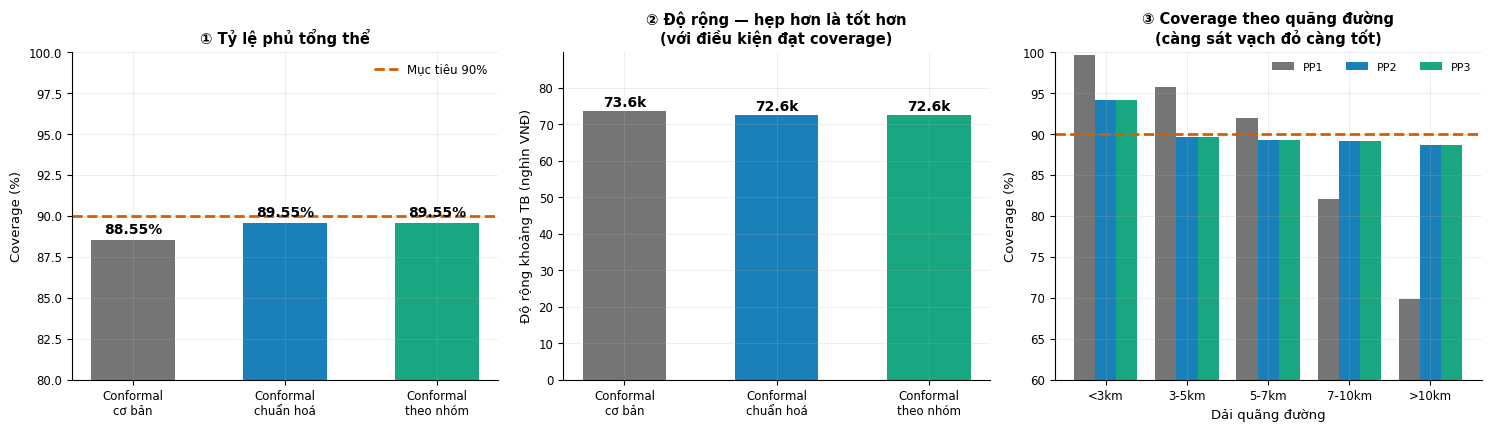

In [7]:
# ═════════ HINH U1 — so sanh 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
TEN_PP = ["Conformal\ncơ bản", "Conformal\nchuẩn hoá", "Conformal\ntheo nhóm"]
MAU = [MUT, BLUE, GREEN]

# (a) Coverage tong
cov = kq.Coverage.values
b_ = ax[0].bar(range(3), cov, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b_, cov):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+0.4, f"{v:.2f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label=f"Mục tiêu {MUC*100:.0f}%")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(TEN_PP, fontsize=8.5)
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(80, 100)
ax[0].set_title("① Tỷ lệ phủ tổng thể", fontweight="bold"); ax[0].legend(frameon=False)

# (b) Do rong
rong = kq["Do rong TB (d)"].values / 1000
b2 = ax[1].bar(range(3), rong, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b2, rong):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.1f}k", ha="center",
               fontsize=10, fontweight="bold")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(TEN_PP, fontsize=8.5)
ax[1].set_ylabel("Độ rộng khoảng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng — hẹp hơn là tốt hơn\n(với điều kiện đạt coverage)", fontweight="bold")
ax[1].set_ylim(0, max(rong)*1.22)

# (c) Conditional coverage theo dai quang duong
x = np.arange(len(c_dai)); w = 0.26
for i, (col, ten) in enumerate(zip(MAU, ["PP1", "PP2", "PP3"])):
    ax[2].bar(x + (i-1)*w, c_dai[f"PP{i+1}"], w, color=col, alpha=0.9, label=ten)
ax[2].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[2].set_xticks(x); ax[2].set_xticklabels(c_dai.Nhom, fontsize=8.5)
ax[2].set_xlabel("Dải quãng đường"); ax[2].set_ylabel("Coverage (%)")
ax[2].set_title("③ Coverage theo quãng đường\n(càng sát vạch đỏ càng tốt)", fontweight="bold")
ax[2].set_ylim(60, 100); ax[2].legend(frameon=False, ncol=3, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "UQ1_so_sanh_conformal.png"); plt.show()

## 6. Ví dụ đọc được — 10 chuyến cụ thể

In [8]:
mau = tes.sample(10, random_state=42).sort_values("gia_that")
bang = pd.DataFrame({
    "Quang duong": mau.quote_distance.round(2).values,
    "Gio": mau.gio_vn.values,
    "Gia THAT": mau.gia_that.round(0).values,
    "Du doan": mau.hybrid_pred.round(0).values,
    "Khoang PP2 (chuan hoa)": [f"[{l:,.0f} - {h:,.0f}]" for l, h in zip(mau.low_2, mau.high_2)],
    "Do rong": (mau.high_2 - mau.low_2).round(0).values,
    "Co phu?": np.where((mau.gia_that >= mau.low_2) & (mau.gia_that <= mau.high_2), "CO", "KHONG"),
})
display(bang)
print(f"Trong 10 chuyen nay: phu {(bang['Co phu?']=='CO').sum()}/10")

,Quang duong,Gio,Gia THAT,Du doan,Khoang PP2 (chuan hoa),Do rong,Co phu?
0,5.14,4,57000.0,77104.0,"[53,904 - 100,305]",46401.0,CO
1,5.00,17,76000.0,110447.0,"[77,214 - 143,681]",66467.0,KHONG
2,8.96,17,107000.0,173514.0,"[121,303 - 225,724]",104420.0,KHONG
3,6.29,9,118000.0,113507.0,"[79,353 - 147,661]",68308.0,CO
4,5.33,11,126000.0,137709.0,"[96,272 - 179,145]",82873.0,CO
5,13.18,1,138000.0,161392.0,"[112,829 - 209,955]",97126.0,CO
6,5.36,14,145000.0,103538.0,"[72,384 - 134,693]",62309.0,KHONG
7,6.12,0,145000.0,120789.0,"[84,443 - 157,134]",72690.0,CO
8,5.66,19,192000.0,148522.0,"[103,832 - 193,213]",89381.0,CO
9,8.14,19,215000.0,199309.0,"[139,337 - 259,281]",119944.0,CO


Trong 10 chuyen nay: phu 7/10


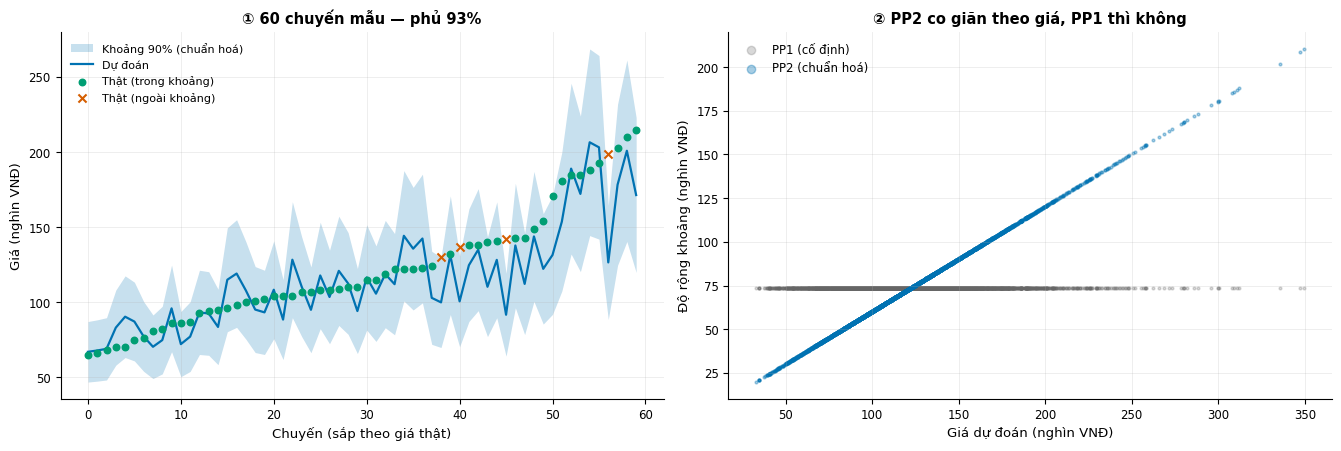

In [9]:
# ═════════ HINH U2 — truc quan khoang du doan ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

# (a) 60 chuyen dau, sap theo gia that
s = tes.sample(60, random_state=7).sort_values("gia_that").reset_index(drop=True)
i = np.arange(len(s))
ax[0].fill_between(i, s.low_2/1000, s.high_2/1000, color=BLUE, alpha=0.22, lw=0,
                   label="Khoảng 90% (chuẩn hoá)")
ax[0].plot(i, s.hybrid_pred/1000, color=BLUE, lw=1.6, label="Dự đoán")
trong = (s.gia_that >= s.low_2) & (s.gia_that <= s.high_2)
ax[0].scatter(i[trong], s.gia_that[trong]/1000, s=22, color=GREEN, zorder=5, label="Thật (trong khoảng)")
ax[0].scatter(i[~trong], s.gia_that[~trong]/1000, s=34, color=RED, marker="x", zorder=5,
              label="Thật (ngoài khoảng)")
ax[0].set_xlabel("Chuyến (sắp theo giá thật)"); ax[0].set_ylabel("Giá (nghìn VNĐ)")
ax[0].set_title(f"① 60 chuyến mẫu — phủ {trong.mean()*100:.0f}%", fontweight="bold")
ax[0].legend(frameon=False, fontsize=8)

# (b) Do rong khoang theo gia du doan
ax[1].scatter(tes.hybrid_pred.sample(4000, random_state=1)/1000,
              (tes.high_1 - tes.low_1).sample(4000, random_state=1)/1000,
              s=4, alpha=0.25, color=MUT, label="PP1 (cố định)")
ax[1].scatter(tes.hybrid_pred.sample(4000, random_state=1)/1000,
              (tes.high_2 - tes.low_2).sample(4000, random_state=1)/1000,
              s=4, alpha=0.35, color=BLUE, label="PP2 (chuẩn hoá)")
ax[1].set_xlabel("Giá dự đoán (nghìn VNĐ)"); ax[1].set_ylabel("Độ rộng khoảng (nghìn VNĐ)")
ax[1].set_title("② PP2 co giãn theo giá, PP1 thì không", fontweight="bold")
ax[1].legend(frameon=False, markerscale=3)

plt.tight_layout(); plt.savefig(HINH / "UQ2_khoang_du_doan.png"); plt.show()

## 7. Kết luận

In [10]:
print("=" * 66)
print("TOM TAT UNCERTAINTY QUANTIFICATION")
print("=" * 66)
best = kq.iloc[kq["Do rong TB (d)"].idxmin()]
print(f"  Muc tin cay muc tieu : {MUC*100:.0f}%")
print()
for _, r in kq.iterrows():
    print(f"  {r['Phuong phap']:26s} coverage {r['Coverage']:6.2f}%  "
          f"| rong {r['Do rong TB (d)']:>9,.0f}d ({r['Do rong / gia (%)']:.1f}% gia)")
print()
print(f"  Nguong chuan hoa: +/- {q_rel*100:.2f}% quanh gia du doan")
print(f"  Vi du: du doan 114.000d -> khoang [{114000*(1-q_rel):,.0f} - {114000*(1+q_rel):,.0f}]")

TOM TAT UNCERTAINTY QUANTIFICATION
  Muc tin cay muc tieu : 90%

  1. Conformal co ban        coverage  88.55%  | rong    73,611d (69.1% gia)
  2. Conformal chuan hoa     coverage  89.55%  | rong    72,630d (61.1% gia)
  3. Conformal theo nhom     coverage  89.55%  | rong    72,626d (61.1% gia)

  Nguong chuan hoa: +/- 30.09% quanh gia du doan
  Vi du: du doan 114.000d -> khoang [79,697 - 148,303]


### Kết quả chính

| Phương pháp | Ưu | Nhược |
|---|---|---|
| **1. Cơ bản** | Đơn giản nhất | Khoảng **cố định** — quá rộng cho chuyến ngắn, quá hẹp cho chuyến dài |
| **2. Chuẩn hoá** ⭐ | Co giãn theo giá, **conditional coverage tốt hơn** | Cần giả định sai số tỷ lệ thuận với giá (đã kiểm chứng) |
| **3. Theo nhóm** | Sát mục tiêu ở **từng khung giờ** | Phức tạp hơn, cần đủ mẫu mỗi nhóm |

### Vì sao chuẩn hoá thắng

Đã đo trên `calibration`: sai số **tuyệt đối** biến thiên mạnh giữa các dải quãng đường, còn sai số
**tương đối** thì ổn định. Đây là hệ quả trực tiếp của phát hiện **MAPE phẳng** ở tuần 2.

### ⚠️ Giới hạn

| Điểm | Chi tiết |
|---|---|
| **Giả định trao đổi được** | Conformal cần calibration và test **cùng phân phối**. Ở đây tách theo thời gian trong cùng tháng — hợp lý nhưng không tuyệt đối |
| **Không bảo đảm theo nhóm** | PP1 và PP2 chỉ bảo đảm coverage **tổng**, không bảo đảm từng nhóm. PP3 khắc phục |
| **Model đã cố định** | UQ không cải thiện dự đoán, chỉ **đo** độ bất định của model hiện có |

### Bước tiếp theo

| # | Việc |
|---|---|
| 1 | Thêm **Quantile Regression** để so sánh với conformal |
| 2 | Nối khoảng dự đoán vào **acceptance model** — định giá thận trọng khi khoảng rộng |
| 3 | Kiểm tra coverage theo **độ trễ quan sát** (lag 5/10/15/30) |